## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import requests

from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("api_key")

url = f"https://api.eia.gov/v2/electricity/retail-sales/data/?frequency=monthly&data[0]=price&facets[sectorid][]=ALL&facets[stateid][]=AZ&start=2019-01&end=2024-12&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000&api_key={api_key}"

response = requests.get(url)
data = response.json()
df_electricity = pd.DataFrame(data['response']['data'])
print(df_electricity.head())

    period stateid stateDescription sectorid   sectorName  price  \
0  2024-12      AZ          Arizona      ALL  all sectors  12.23   
1  2024-11      AZ          Arizona      ALL  all sectors  12.12   
2  2024-10      AZ          Arizona      ALL  all sectors  12.72   
3  2024-09      AZ          Arizona      ALL  all sectors  12.97   
4  2024-08      AZ          Arizona      ALL  all sectors  13.33   

               price-units  
0  cents per kilowatt-hour  
1  cents per kilowatt-hour  
2  cents per kilowatt-hour  
3  cents per kilowatt-hour  
4  cents per kilowatt-hour  


In [3]:
df_electricity.to_csv('arizona_electricity.csv', index = False)
print('Saved.')

Saved.


In [4]:
url_gas = f"https://api.eia.gov/v2/natural-gas/pri/fut/data/?frequency=monthly&data[0]=value&facets[product][]=EPG0&facets[series][]=RNGWHHD&start=2019-01&end=2024-12&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000&api_key={api_key}"

response_gas = requests.get(url_gas)
data_gas = response_gas.json()
df_gas = pd.DataFrame(data_gas['response']['data'])
print(df_gas.head())

    period duoarea area-name product product-name process process-name  \
0  2024-12     RGC        NA    EPG0  Natural Gas     PS0   Spot Price   
1  2024-11     RGC        NA    EPG0  Natural Gas     PS0   Spot Price   
2  2024-10     RGC        NA    EPG0  Natural Gas     PS0   Spot Price   
3  2024-09     RGC        NA    EPG0  Natural Gas     PS0   Spot Price   
4  2024-08     RGC        NA    EPG0  Natural Gas     PS0   Spot Price   

    series                                 series-description value    units  
0  RNGWHHD  Henry Hub Natural Gas Spot Price (Dollars per ...  3.01  $/MMBTU  
1  RNGWHHD  Henry Hub Natural Gas Spot Price (Dollars per ...  2.12  $/MMBTU  
2  RNGWHHD  Henry Hub Natural Gas Spot Price (Dollars per ...   2.2  $/MMBTU  
3  RNGWHHD  Henry Hub Natural Gas Spot Price (Dollars per ...  2.28  $/MMBTU  
4  RNGWHHD  Henry Hub Natural Gas Spot Price (Dollars per ...  1.99  $/MMBTU  


In [5]:
df_gas.to_csv('natural_gas.csv', index = False)
print('Saved.')

Saved.


In [6]:
df_electricity = pd.read_csv("arizona_electricity.csv")
df_gas = pd.read_csv("natural_gas.csv")

In [7]:
df_electricity.head()

,period,stateid,stateDescription,sectorid,sectorName,price,price-units
0,2024-12,AZ,Arizona,ALL,all sectors,12.23,cents per kilowatt-hour
1,2024-11,AZ,Arizona,ALL,all sectors,12.12,cents per kilowatt-hour
2,2024-10,AZ,Arizona,ALL,all sectors,12.72,cents per kilowatt-hour
3,2024-09,AZ,Arizona,ALL,all sectors,12.97,cents per kilowatt-hour
4,2024-08,AZ,Arizona,ALL,all sectors,13.33,cents per kilowatt-hour


In [8]:
df_electricity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   period            72 non-null     object 
 1   stateid           72 non-null     object 
 2   stateDescription  72 non-null     object 
 3   sectorid          72 non-null     object 
 4   sectorName        72 non-null     object 
 5   price             72 non-null     float64
 6   price-units       72 non-null     object 
dtypes: float64(1), object(6)
memory usage: 4.1+ KB


In [9]:
df_electricity.describe()

,price
count,72.000000
mean,11.193889
std,1.074525
min,9.420000
25%,10.312500
50%,11.150000
75%,11.992500
max,13.480000


In [10]:
df_gas.head()

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,2024-12,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,3.01,$/MMBTU
1,2024-11,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,2.12,$/MMBTU
2,2024-10,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,2.20,$/MMBTU
3,2024-09,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,2.28,$/MMBTU
4,2024-08,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,1.99,$/MMBTU


In [11]:
df_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   period              72 non-null     object 
 1   duoarea             72 non-null     object 
 2   area-name           0 non-null      float64
 3   product             72 non-null     object 
 4   product-name        72 non-null     object 
 5   process             72 non-null     object 
 6   process-name        72 non-null     object 
 7   series              72 non-null     object 
 8   series-description  72 non-null     object 
 9   value               72 non-null     float64
 10  units               72 non-null     object 
dtypes: float64(2), object(9)
memory usage: 6.3+ KB


## Data Cleaning & Merging

In [12]:
df_electricity['period'] = pd.to_datetime(df_electricity['period'])

In [13]:
df_electricity['month'] = df_electricity['period'].dt.month

In [14]:
df_electricity['year'] = df_electricity['period'].dt.year

In [15]:
df_electricity['quarter'] = df_electricity['period'].dt.quarter

In [16]:
df_electricity["season"] = df_electricity['month'].map({12:"Winter", 1:"Winter", 2:"Winter", 3:"Spring", 4:"Spring", 5:"Spring", 6:"Summer", 7:"Summer", 8:"Summer", 9:"Fall", 10:"Fall", 11:"Fall"})

In [17]:
df_electricity.head()

,period,stateid,stateDescription,sectorid,sectorName,price,price-units,month,year,quarter,season
0,2024-12-01,AZ,Arizona,ALL,all sectors,12.23,cents per kilowatt-hour,12,2024,4,Winter
1,2024-11-01,AZ,Arizona,ALL,all sectors,12.12,cents per kilowatt-hour,11,2024,4,Fall
2,2024-10-01,AZ,Arizona,ALL,all sectors,12.72,cents per kilowatt-hour,10,2024,4,Fall
3,2024-09-01,AZ,Arizona,ALL,all sectors,12.97,cents per kilowatt-hour,9,2024,3,Fall
4,2024-08-01,AZ,Arizona,ALL,all sectors,13.33,cents per kilowatt-hour,8,2024,3,Summer


In [18]:
df_gas['period'] = pd.to_datetime(df_gas['period'])

In [19]:
df_gas['month'] = df_gas['period'].dt.month

In [20]:
df_gas['year'] = df_gas['period'].dt.year

In [21]:
df_gas['quarter'] = df_gas['period'].dt.quarter

In [22]:
df_gas["season"] = df_gas['month'].map({12:"Winter", 1:"Winter", 2:"Winter", 3:"Spring", 4:"Spring", 5:"Spring", 6:"Summer", 7:"Summer", 8:"Summer", 9:"Fall", 10:"Fall", 11:"Fall"})

In [23]:
df_gas.head()

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units,month,year,quarter,season
0,2024-12-01,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,3.01,$/MMBTU,12,2024,4,Winter
1,2024-11-01,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,2.12,$/MMBTU,11,2024,4,Fall
2,2024-10-01,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,2.20,$/MMBTU,10,2024,4,Fall
3,2024-09-01,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,2.28,$/MMBTU,9,2024,3,Fall
4,2024-08-01,RGC,NaN,EPG0,Natural Gas,PS0,Spot Price,RNGWHHD,Henry Hub Natural Gas Spot Price (Dollars per ...,1.99,$/MMBTU,8,2024,3,Summer


In [24]:
df_electricity = df_electricity[["period", "price", "month", "year", "quarter", "season"]]

In [25]:
df_electricity = df_electricity.rename(columns={'price':'electricity_price'})

In [26]:
df_electricity.isnull().sum()

period               0
electricity_price    0
month                0
year                 0
quarter              0
season               0
dtype: int64

In [27]:
df_gas = df_gas.rename(columns={'value':'gas_price'})

In [28]:
df_gas = df_gas[["period", "gas_price"]]

In [29]:
df_merged = pd.merge(df_electricity, df_gas, on='period', how='inner')

In [30]:
df_merged.head()

,period,electricity_price,month,year,quarter,season,gas_price
0,2024-12-01,12.23,12,2024,4,Winter,3.01
1,2024-11-01,12.12,11,2024,4,Fall,2.12
2,2024-10-01,12.72,10,2024,4,Fall,2.20
3,2024-09-01,12.97,9,2024,3,Fall,2.28
4,2024-08-01,13.33,8,2024,3,Summer,1.99


In [31]:
df_merged.shape

(72, 7)

## Exploratory Analysis

In [32]:
df_merged.isnull().sum()

period               0
electricity_price    0
month                0
year                 0
quarter              0
season               0
gas_price            0
dtype: int64

In [33]:
np.mean(df_merged['electricity_price'])

np.float64(11.193888888888889)

In [34]:
np.std(df_merged["electricity_price"])

1.0670371173846498

In [35]:
np.percentile(df_merged["electricity_price"], 75)

np.float64(11.9925)

In [36]:
np.percentile(df_merged["electricity_price"], 25)

np.float64(10.3125)

In [37]:
df_merged.groupby('season')['electricity_price'].mean()

season
Fall      11.191667
Spring    11.018889
Summer    11.958333
Winter    10.606667
Name: electricity_price, dtype: float64

In [38]:
df_merged.groupby('month')['electricity_price'].mean()

month
1     10.401667
2     10.563333
3     10.446667
4     10.953333
5     11.656667
6     11.838333
7     12.116667
8     11.920000
9     11.678333
10    11.226667
11    10.670000
12    10.855000
Name: electricity_price, dtype: float64

In [39]:
df_merged.groupby('year')['electricity_price'].mean()

year
2019    10.414167
2020    10.280833
2021    10.603333
2022    11.191667
2023    12.065833
2024    12.607500
Name: electricity_price, dtype: float64

Electricity prices dipped in 2020 (10.41 -> 10.28) before rising sharply from 2022 onward. The 2020 dip coincides with COVID-19, though the dataset doesn't isolate demand effects directly, so this is a plausible explanation rather than a confirmed one.

In [40]:
df_merged.groupby('year')['electricity_price'].max()

year
2019    11.34
2020    11.36
2021    11.51
2022    12.03
2023    13.01
2024    13.48
Name: electricity_price, dtype: float64

In [41]:
Summer = df_merged.groupby('season')['electricity_price'].mean()['Summer']

In [42]:
Winter = df_merged.groupby('season')['electricity_price'].mean()['Winter']

In [43]:
print (f'The average electricity price in Summer is {(Summer - Winter) / Winter * 100:.1f}% higher than in Winter')

The average electricity price in Summer is 12.7% higher than in Winter


In [44]:
df_merged[['electricity_price','gas_price']].corr()

,electricity_price,gas_price
electricity_price,1.000000,-0.018816
gas_price,-0.018816,1.000000


Contrary to expectations, gas and electricity prices show no linear relationship (r = -0.019), plausibly reflecting Arizona's regulated pricing structure rather than a direct causal link.

In [45]:
df_merged.loc[df_merged.groupby("year")["electricity_price"].idxmax()]

,period,electricity_price,month,year,quarter,season,gas_price
65,2019-07-01,11.34,7,2019,3,Summer,2.37
53,2020-07-01,11.36,7,2020,3,Summer,1.76
41,2021-07-01,11.51,7,2021,3,Summer,3.84
28,2022-08-01,12.03,8,2022,3,Summer,8.81
17,2023-07-01,13.01,7,2023,3,Summer,2.55
5,2024-07-01,13.48,7,2024,3,Summer,2.07


Supporting the previous data, the most expensive prices for electricity tend to be in July, with exception for 2022, where peak fell on August, which also was the gas price spike month.

In [46]:
df_merged.sort_values('electricity_price', ascending=False).head(3)

,period,electricity_price,month,year,quarter,season,gas_price
5,2024-07-01,13.48,7,2024,3,Summer,2.07
4,2024-08-01,13.33,8,2024,3,Summer,1.99
6,2024-06-01,13.33,6,2024,2,Summer,2.54


## Visualizations

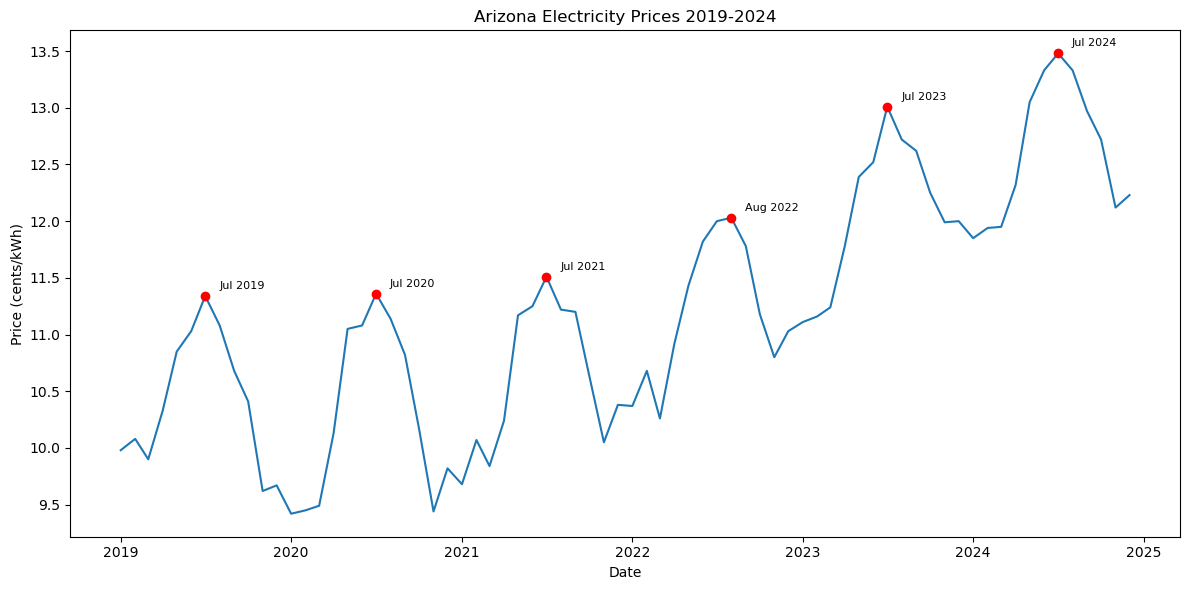

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df_merged['period'],df_merged['electricity_price'])
peaks = df_merged.loc[df_merged.groupby("year")["electricity_price"].idxmax()]
for _, row in peaks.iterrows():
    plt.annotate(row['period'].strftime("%b %Y"), 
             xy=(row['period'], row['electricity_price']),
             xytext=(10, 5), textcoords='offset points',
             fontsize=8)
plt.scatter(peaks["period"], peaks["electricity_price"], color="red", zorder=5)
plt.title('Arizona Electricity Prices 2019-2024')
plt.xlabel('Date')
plt.ylabel('Price (cents/kWh)')
plt.tight_layout()
plt.savefig('chart1_line_prices.png')
plt.show()

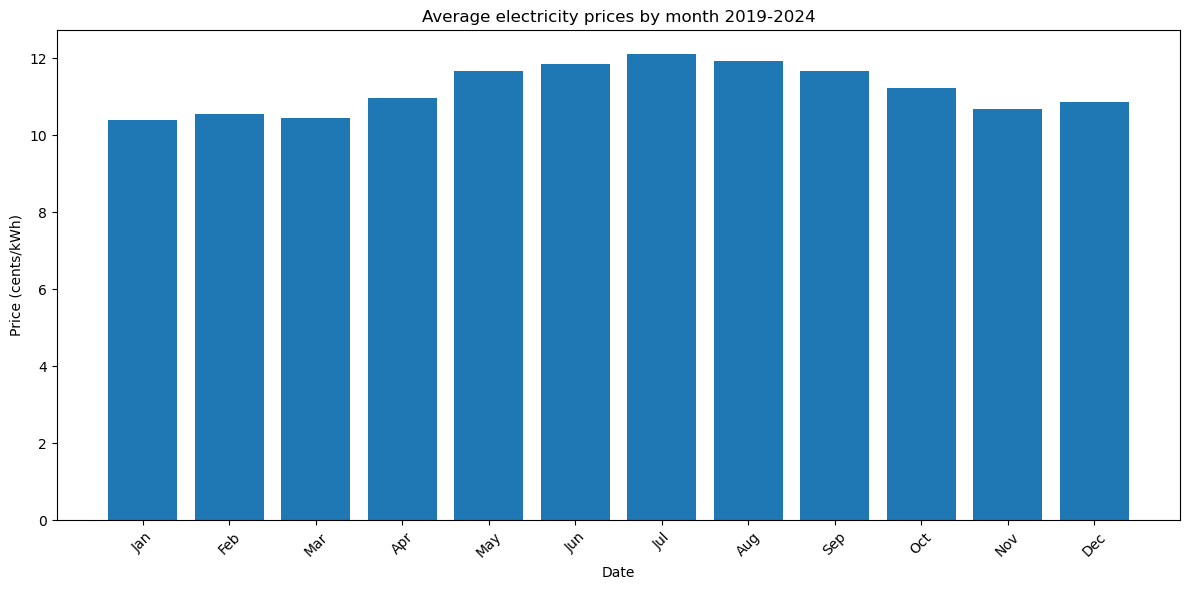

In [48]:
monthly_avg = df_merged.groupby("month")["electricity_price"].mean()
plt.figure(figsize=(12,6))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title('Average electricity prices by month 2019-2024')
plt.xlabel('Date')
plt.ylabel('Price (cents/kWh)')
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(monthly_avg.index, month_names, rotation=45)
plt.tight_layout()
plt.savefig('chart2_bar_monthly.png')
plt.show()

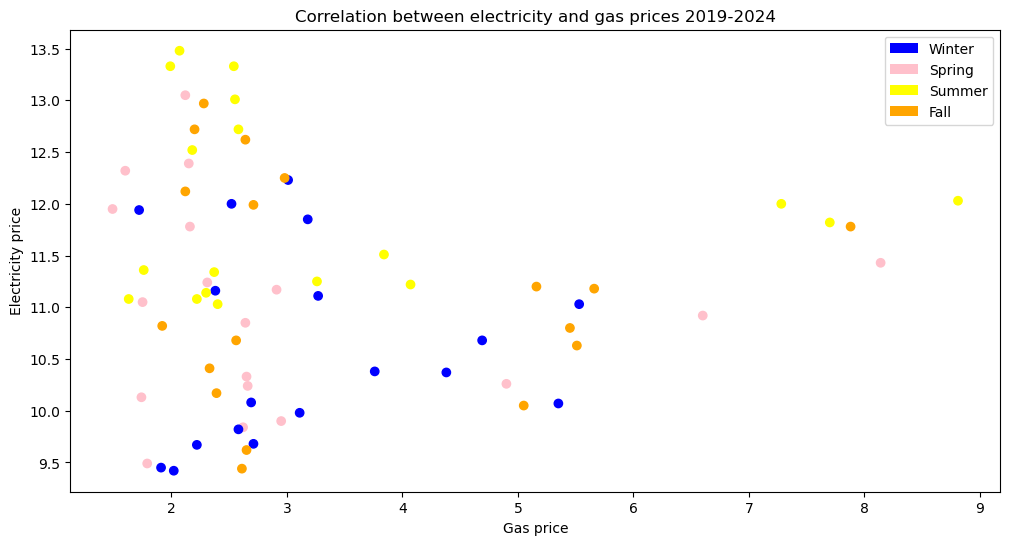

In [49]:
season_colors = {"Spring": "pink", "Summer": "yellow", "Fall": "orange", "Winter": "blue"}
colors = df_merged["season"].map(season_colors)

plt.figure(figsize=(12,6))
plt.scatter(df_merged['gas_price'], df_merged['electricity_price'], c=colors)
plt.title('Correlation between electricity and gas prices 2019-2024')
plt.xlabel('Gas price')
plt.ylabel('Electricity price')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Winter'),
                   Patch(facecolor='pink', label='Spring'),
                   Patch(facecolor='yellow', label='Summer'),
                   Patch(facecolor='orange', label='Fall')]
plt.legend(handles=legend_elements)
plt.savefig('chart3_scatter_correlation.png')
plt.show()

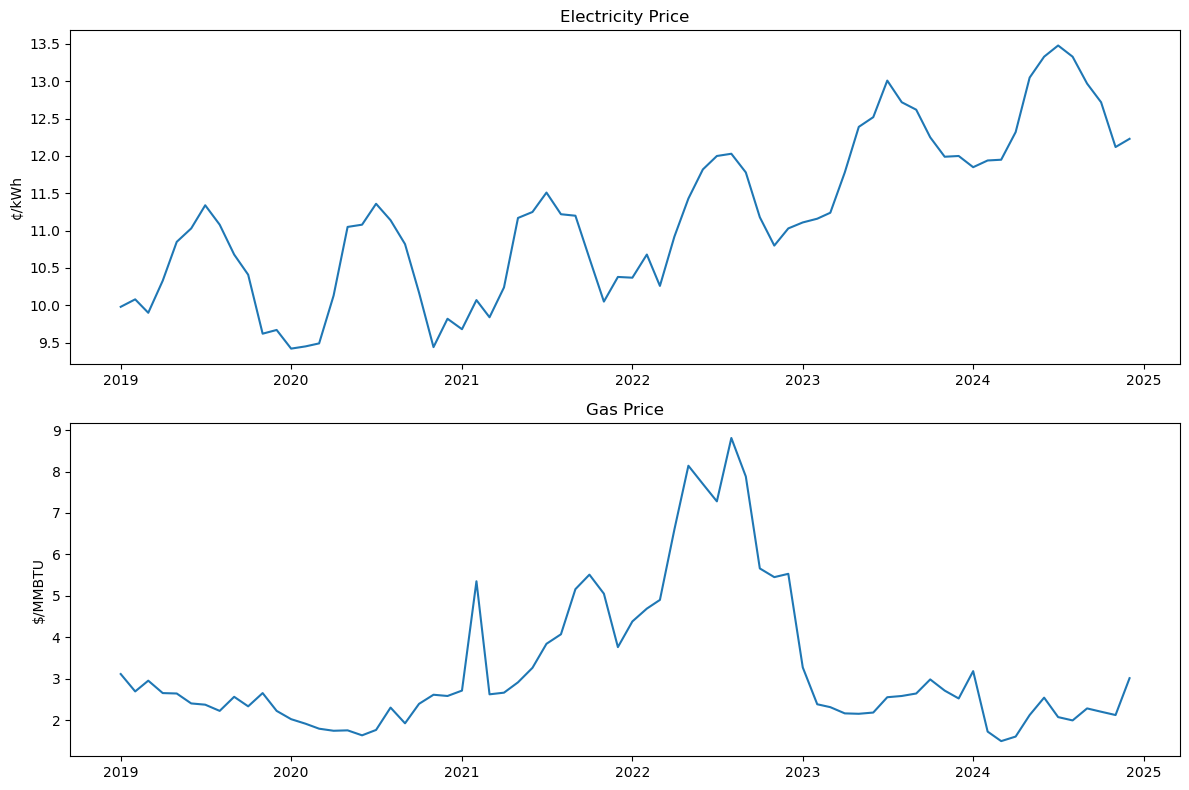

In [50]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (12,8))

ax1.plot(df_merged['period'], df_merged['electricity_price'])

ax1.set_title('Electricity Price')

ax1.set_ylabel('¢/kWh')



ax2.plot(df_merged['period'], df_merged['gas_price'])

ax2.set_title('Gas Price')

ax2.set_ylabel('$/MMBTU')



plt.tight_layout()

plt.savefig('chart4_subplot_comparison.png')

plt.show()

In [51]:
pivot = df_merged.pivot_table(values='electricity_price', index='year', columns='month', aggfunc='mean')

In [52]:
pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2019,9.98,10.08,9.90,10.33,10.85,11.03,11.34,11.08,10.68,10.41,9.62,9.67
2020,9.42,9.45,9.49,10.13,11.05,11.08,11.36,11.14,10.82,10.17,9.44,9.82
2021,9.68,10.07,9.84,10.24,11.17,11.25,11.51,11.22,11.20,10.63,10.05,10.38
2022,10.37,10.68,10.26,10.92,11.43,11.82,12.00,12.03,11.78,11.18,10.80,11.03
2023,11.11,11.16,11.24,11.78,12.39,12.52,13.01,12.72,12.62,12.25,11.99,12.00
2024,11.85,11.94,11.95,12.32,13.05,13.33,13.48,13.33,12.97,12.72,12.12,12.23


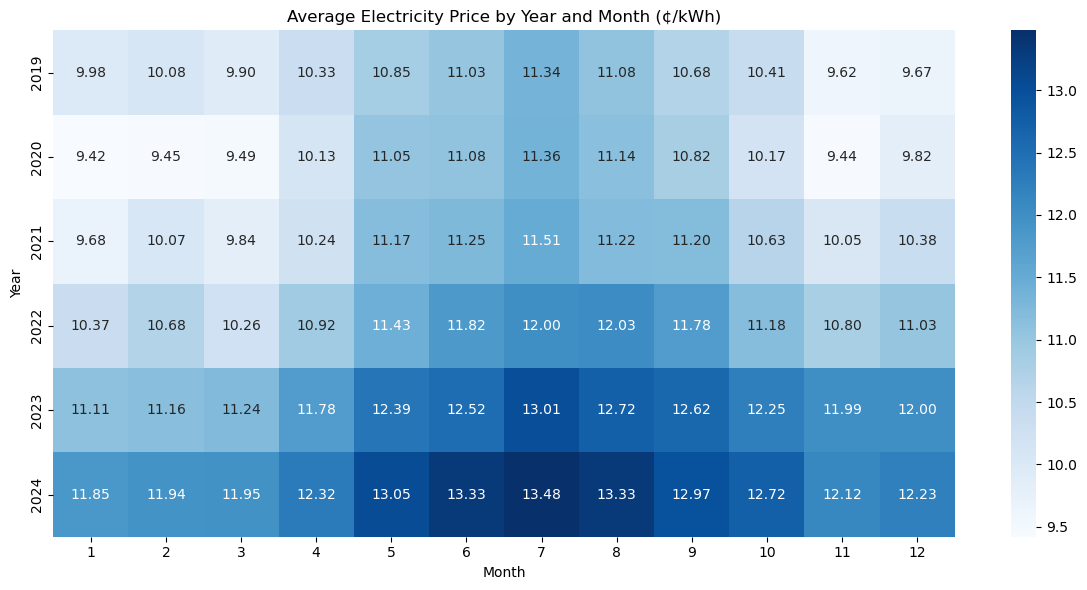

In [53]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues')
plt.title('Average Electricity Price by Year and Month (¢/kWh)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig("chart5_heatmap_seasonality.png")
plt.show()

## Model v1: Baseline (month as numeric)

In [54]:
y = df_merged['electricity_price']
X = df_merged[['month', 'gas_price', 'year']]

train = df_merged[df_merged['year'] < 2024]
test = df_merged[df_merged['year'] == 2024]

X_train = train[['month', 'gas_price', 'year']]
y_train = train['electricity_price']

X_test = test[['month', 'gas_price', 'year']]
y_test = test['electricity_price']

In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

-0.27779648023029724


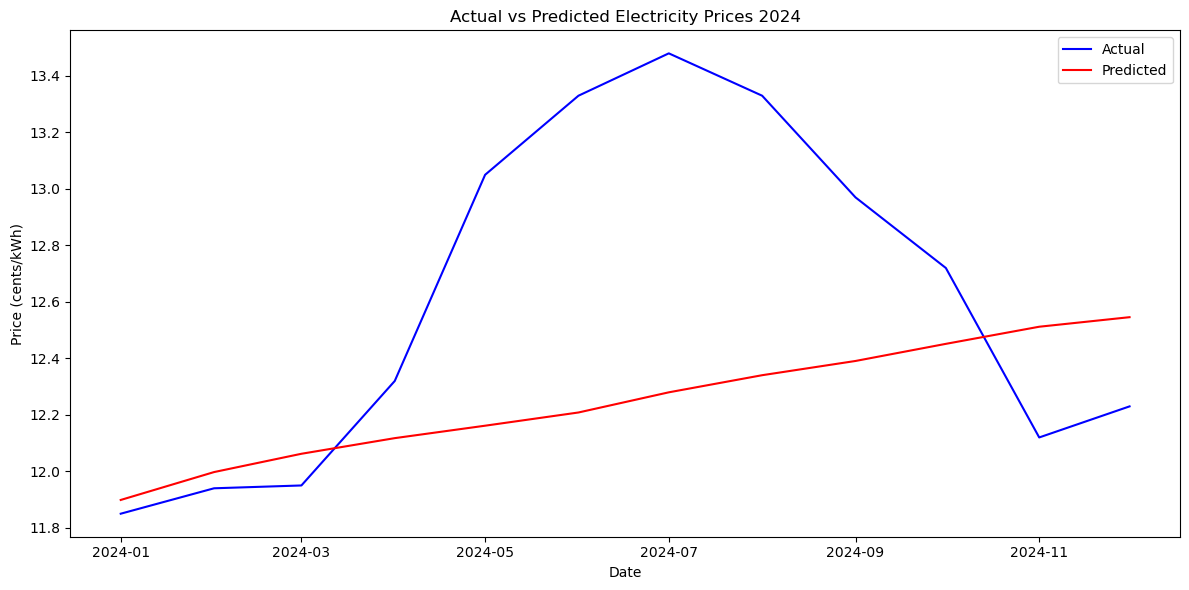

In [56]:
predictions = model.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(test['period'], y_test, label='Actual',color='blue')
plt.plot(test['period'], predictions, label='Predicted',color='red')
plt.title("Actual vs Predicted Electricity Prices 2024")
plt.xlabel("Date")
plt.ylabel("Price (cents/kWh)")
plt.legend()
plt.tight_layout()
plt.savefig("chart6_forecast_vs_actual.png")
plt.show()

The model was trained on 2019-2023 data and tested on unseen 2024 data. It resulted in R² = -0.28, meaning it performed worse than simply predicting the average price. This demonstrates that 2024 prices deviated from the historical linear trend more sharply than the model could anticipate, likely driven by the unusually steep summer price spike visible in the chart above.

In [57]:
df_merged.to_csv("final_data.csv", index=False)

In [58]:
forecast_export = test[['period']].copy()
forecast_export['actual_price'] = y_test.values
forecast_export['predicted_price'] = predictions

## Model v2: Improved (season as categorical) — Final Model

In [59]:
X_dummies = pd.get_dummies(df_merged[['month', 'gas_price', 'year', 'season']], columns=['season'], drop_first=True)

In [60]:
X_dummies.columns.tolist()

['month',
 'gas_price',
 'year',
 'season_Spring',
 'season_Summer',
 'season_Winter']

In [61]:
X_dummies.head()

,month,gas_price,year,season_Spring,season_Summer,season_Winter
0,12,3.01,2024,False,False,True
1,11,2.12,2024,False,False,False
2,10,2.20,2024,False,False,False
3,9,2.28,2024,False,False,False
4,8,1.99,2024,False,True,False


In [62]:
X_train_v2 = X_dummies[df_merged['year'] < 2024]
X_test_v2 = X_dummies[df_merged['year'] == 2024]
y_train_v2 = y[df_merged['year'] < 2024]
y_test_v2 = y[df_merged['year'] == 2024]

In [63]:
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)
print(model_v2.score(X_test_v2, y_test_v2))

0.4367868139654899


Using month as a raw number, the model performed poorly (R² = -0.28) because a linear model cannot capture seasonal patterns when month is encoded numerically - winter months (December=12, January=1) sit at opposite ends of the scale despite being seasonally similar. Encoding season as categorical dummy variables instead allowed the model to learn a direct seasonal effect, improving R² to 0.44.

In [64]:
predictions_v2 = model_v2.predict(X_test_v2)

forecast_export_v2 = test[['period']].copy()
forecast_export_v2['actual_price'] = y_test_v2.values
forecast_export_v2['predicted_price'] = predictions_v2
forecast_export_v2.to_csv('forecast_data.csv', index=False)

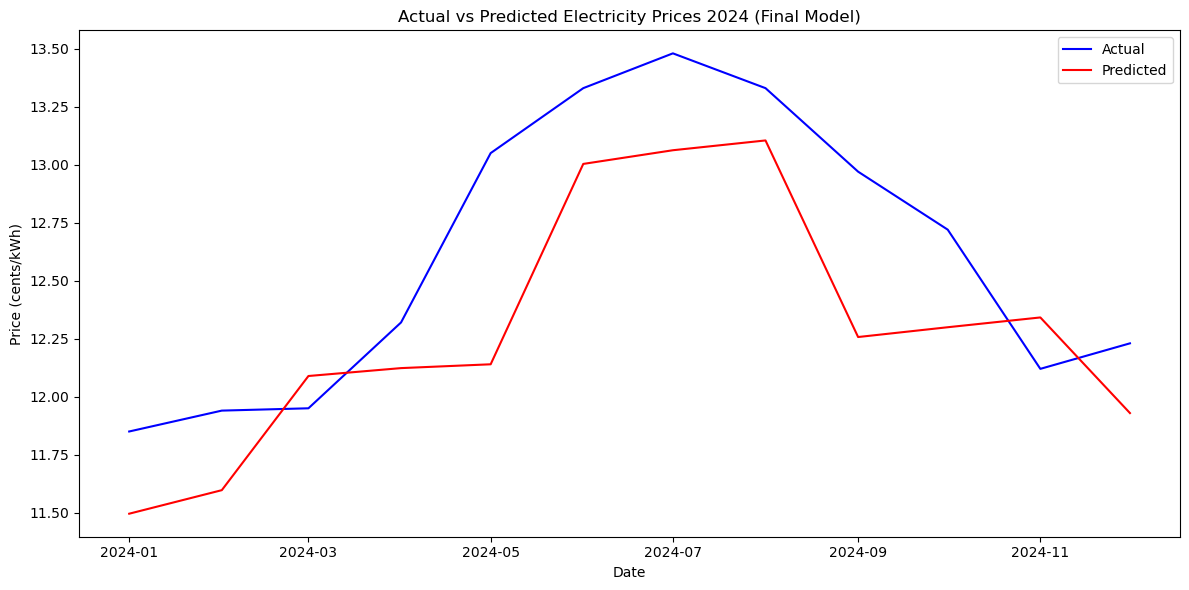

In [65]:
plt.figure(figsize=(12,6))
plt.plot(test['period'], y_test_v2, label='Actual', color='blue')
plt.plot(test['period'], predictions_v2, label='Predicted', color='red')
plt.title("Actual vs Predicted Electricity Prices 2024 (Final Model)")
plt.xlabel("Date")
plt.ylabel("Price (cents/kWh)")
plt.legend()
plt.tight_layout()
plt.savefig("chart7_forecast_vs_actual_v2.png")
plt.show()

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_v2, predictions_v2)
rmse = np.sqrt(mean_squared_error(y_test_v2, predictions_v2))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 0.38, RMSE: 0.44


The model's average error (MAE = 0.38 ¢/kWh) is about 9% of the total price range (9.42–13.48 ¢/kWh) in this dataset - a real but not extreme margin. RMSE (0.44) is only slightly above MAE, indicating errors are fairly consistent across months rather than driven by one large outlier. Together with R²=0.44, this suggests the model captures some seasonal structure but leaves substantial variation unexplained, likely due to the limited feature set.

In [67]:
X_no_gas = df_merged[['month', 'year', 'season']]
X_dummies_no_gas = pd.get_dummies(X_no_gas, columns=['season'], drop_first=True)

X_train_ng = X_dummies_no_gas[df_merged['year'] < 2024]
X_test_ng = X_dummies_no_gas[df_merged['year'] == 2024]

model_no_gas = LinearRegression()
model_no_gas.fit(X_train_ng, y_train_v2)
print(model_no_gas.score(X_test_ng, y_test_v2))

0.19729397009151195


Removing gas_price dropped R² from 0.44 to 0.20, since gas price barely correlates with electricity price on its own (r = -0.02). Possible explanation: gas price may interact with year/month in the full model in a way correlation alone doesn't capture. Test set is only 12 months, so R² is somewhat unstable here. Result noted as a limitation, not fully resolved.